In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Load Dataset

In [2]:
df = pd.read_csv(r'..\Data\Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


### EDA and Data Wrangling

In [3]:
# Check for null value
df.isna().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [4]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [5]:
# Dropping irrelevant unnamed column
df = df.drop('Unnamed: 0', axis=1)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


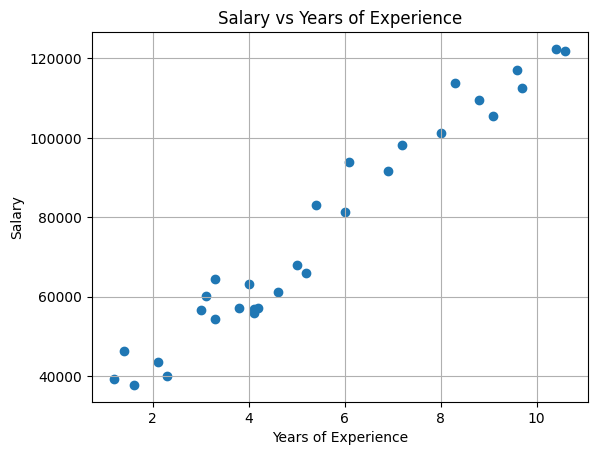

In [6]:
# visualization of data
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.grid(True)
plt.show()

### Split the dataset
Train test split using sklearn

In [7]:
X = df['YearsExperience'].values
y = df['Salary'].values

In [8]:
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (30,)
Shape of y:  (30,)


In [9]:
# Reshape X and y to 2D (n_samples, n_features) because scikit-learn expects a 2D feature matrix.
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

In [10]:
# Mean normalization and feature scaling
X_mean = np.mean(X)
X_std = np.std(X)
X = (X-X_mean)/X_std

y_mean = np.mean(y)
y_std = np.std(y)
y = (y-y_mean)/y_std

In [11]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Implement Linear Regression from Scratch
- `predict()` to make prediction on new data
- `MSE_loss()` to calculate the mean squared error
- `gradient_descent()` to update slope and intercept using gradients 
- `fit()` to calculate the best slope and intercept

In [12]:
class UnivariateLinearRegression():
    def __init__(self, lr=0.01, n_iters=1000):
        self.slope = 0.0
        self.intercept = 0.0
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []
        self.slope_history = []
        self.intercept_history = []

    def MSE_loss(self, y_pred, y):
        m = y.shape[0]
        loss = (1/(2 * m)) * np.sum((y_pred - y)**2)
        return loss

    def gradient_descent(self, X, y, y_pred):
        m = y.shape[0]

        # Derivative of loss wrt slope and intercept
        d_intercept = (1 / m) * np.sum(y_pred - y)
        d_slope = (1 / m) * np.sum(X.flatten() * (y_pred - y))

        self.intercept = self.intercept - self.lr * d_intercept
        self.slope = self.slope - self.lr * d_slope

    def fit(self, X, y):

        X_flat = X.flatten()
        y_flat = y.flatten()

        for i in range(self.n_iters):
            y_pred = self.slope * X_flat + self.intercept
            loss = self.MSE_loss(y_pred, y_flat)
            self.loss_history.append(loss)
            self.slope_history.append(self.slope)
            self.intercept_history.append(self.intercept)

            if i % 100 == 0:
                print(f'Itteration {i} MSE Loss = {loss:.6f}')
                
            self.gradient_descent(X,y_flat,y_pred)
        
        return self
    
    def predict (self,X):
        return self.slope* X.flatten() + self.intercept  

### Train the model 
We will train our univariate linear regression model using the trainig data

In [13]:
model = UnivariateLinearRegression()
model.fit(X_train, y_train)

Itteration 0 MSE Loss = 0.528240
Itteration 100 MSE Loss = 0.077889
Itteration 200 MSE Loss = 0.025596
Itteration 300 MSE Loss = 0.019474
Itteration 400 MSE Loss = 0.018751
Itteration 500 MSE Loss = 0.018665
Itteration 600 MSE Loss = 0.018654
Itteration 700 MSE Loss = 0.018653
Itteration 800 MSE Loss = 0.018653
Itteration 900 MSE Loss = 0.018653


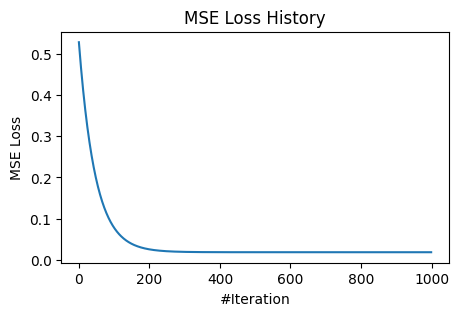

In [14]:
# Plotting Learning Curve
loss_history = model.loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [15]:
# Print original and predicted data side by side
predictions = model.predict(X)
comparison_df = pd.DataFrame({
    'Original (y)': y.flatten(),
    'Predicted': predictions.flatten()
})
print(comparison_df.head(10))  # Print first 10 rows

   Original (y)  Predicted
0     -1.360113  -1.495702
1     -1.105527  -1.425777
2     -1.419919  -1.355853
3     -1.204957  -1.181042
4     -1.339781  -1.111117
5     -0.718307  -0.866382
6     -0.588158  -0.831420
7     -0.799817  -0.761496
8     -0.428810  -0.761496
9     -0.698013  -0.586685


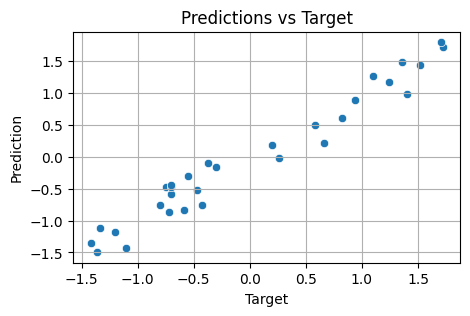

In [16]:
# Plotting predictions vs target
predictions = model.predict(X)
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y.flatten(), y=predictions.flatten())
plt.title("Predictions vs Target")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.grid()
plt.show()

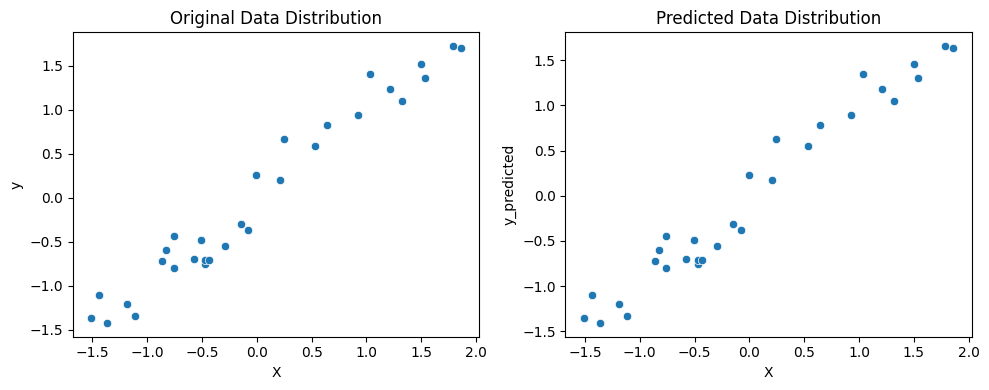

In [17]:
# Original Data Distribution 
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
sns.scatterplot(x=X[:, 0], y=y[:, 0])
plt.title("Original Data Distribution")
plt.xlabel("X")
plt.ylabel("y")

plt.subplot(1,2,2)
sns.scatterplot(x=X[:, 0], y=model.predict(y[:, 0]))
plt.title("Predicted Data Distribution")
plt.xlabel("X")
plt.ylabel("y_predicted")
plt.tight_layout()
plt.show()

### Comparison between Custom and Scikit-learn Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
model_custom = UnivariateLinearRegression()
model_custom.fit(X_train, y_train)
y_pred_custom = model_custom.predict(X_test)

Itteration 0 MSE Loss = 0.528240
Itteration 100 MSE Loss = 0.077889
Itteration 200 MSE Loss = 0.025596
Itteration 300 MSE Loss = 0.019474
Itteration 400 MSE Loss = 0.018751
Itteration 500 MSE Loss = 0.018665
Itteration 600 MSE Loss = 0.018654
Itteration 700 MSE Loss = 0.018653
Itteration 800 MSE Loss = 0.018653
Itteration 900 MSE Loss = 0.018653


In [20]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)

In [21]:
# MSE and R2 for custom model
mse_custom = mean_squared_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)

# MSE and R2 for sklearn model
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print("Evaluation Comparison")
print(f"Custom Model     - MSE: {mse_custom:.8f}, R2 Score: {r2_custom:.8f}")
print(f"Scikit-learn     - MSE: {mse_sklearn:.8f}, R2 Score: {r2_sklearn:.8f}")


Evaluation Comparison
Custom Model     - MSE: 0.06859297, R2 Score: 0.90244099
Scikit-learn     - MSE: 0.06858933, R2 Score: 0.90244618
